# Bland-Altman Analysis: Comparing Two Measurement Methods
## Gen 575 – Fundamentals of Biomedical Instrumentation

When you develop a new measurement method, a critical question is: **"Does the new method agree with the existing one?"**

A common mistake is to plot Method A vs Method B and compute a correlation coefficient. But correlation tells you about *association*, not *agreement* — two methods can be highly correlated but systematically biased.

The **Bland-Altman plot** (Altman & Bland, *The Statistician*, 1983) addresses this directly by plotting:
- **x-axis:** Average of the two methods: (A + B) / 2
- **y-axis:** Difference between the two methods: A − B

This reveals:
- **Bias** (systematic offset): Is the mean difference centered at zero?
- **Limits of agreement**: How large are the differences in practice?
- **Proportional bias**: Does the disagreement change with the magnitude of the measurement?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

np.random.seed(575)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Part 1: Why Correlation Is Not Enough

Consider two methods for measuring protein concentration. We'll generate data where Method B has a systematic bias, then show why the correlation plot is misleading.

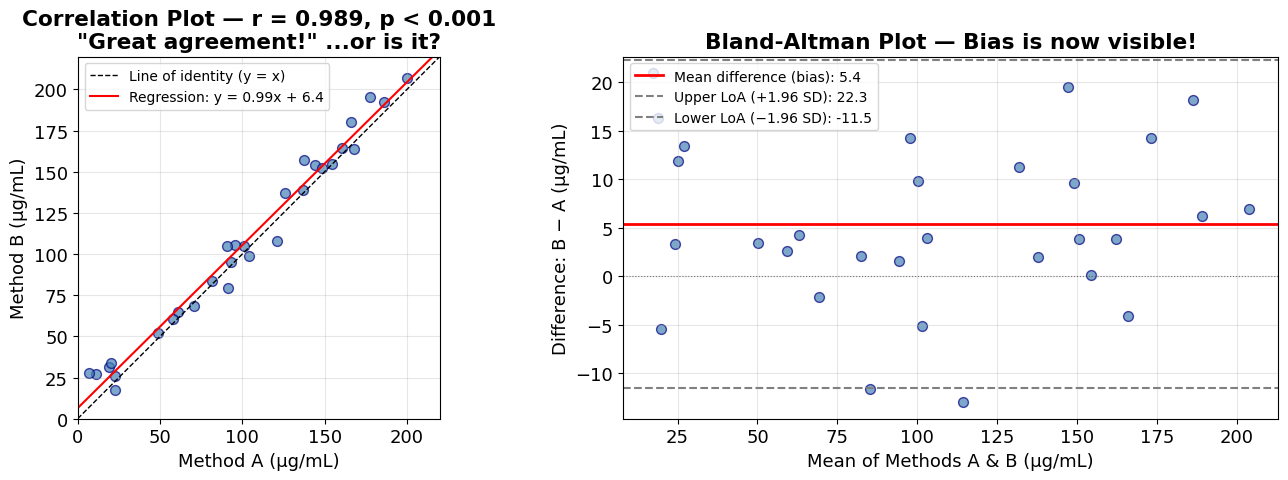

The correlation coefficient r = 0.989 suggests excellent agreement.
But the Bland-Altman plot reveals a systematic bias of 5.4 µg/mL!
Method B consistently reads HIGHER than Method A.


In [ ]:
# Simulate: 30 samples measured by two methods
n_samples = 30
true_concentration = np.random.uniform(10, 200, n_samples)  # µg/mL

# Method A: the reference method (small random error)
method_A = true_concentration + np.random.normal(0, 5, n_samples)

# Method B: new method with a SYSTEMATIC BIAS of +8 µg/mL and slightly more noise
method_B = true_concentration + 8 + np.random.normal(0, 8, n_samples)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Correlation plot (misleading!)
r, p = stats.pearsonr(method_A, method_B)
ax1.scatter(method_A, method_B, s=50, alpha=0.7, color='steelblue', edgecolors='navy')
ax1.plot([0, 220], [0, 220], 'k--', linewidth=1, label='Line of identity (y = x)')
# Regression line
slope, intercept = np.polyfit(method_A, method_B, 1)
x_fit = np.array([0, 220])
ax1.plot(x_fit, slope * x_fit + intercept, 'r-', linewidth=1.5, 
         label=f'Regression: y = {slope:.2f}x + {intercept:.1f}')
ax1.set_xlabel('Method A (µg/mL)')
ax1.set_ylabel('Method B (µg/mL)')
ax1.set_title(f'Correlation Plot — r = {r:.3f}, p < 0.001\n"Great agreement!" ...or is it?', 
               fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(0, 220)
ax1.set_ylim(0, 220)
ax1.set_aspect('equal')

# Bland-Altman plot (reveals the truth)
mean_AB = (method_A + method_B) / 2
diff_AB = method_B - method_A  # new - reference
mean_diff = np.mean(diff_AB)
sd_diff = np.std(diff_AB, ddof=1)
upper_loa = mean_diff + 1.96 * sd_diff
lower_loa = mean_diff - 1.96 * sd_diff

ax2.scatter(mean_AB, diff_AB, s=50, alpha=0.7, color='steelblue', edgecolors='navy')
ax2.axhline(y=mean_diff, color='red', linestyle='-', linewidth=2, 
            label=f'Mean difference (bias): {mean_diff:.1f}')
ax2.axhline(y=upper_loa, color='gray', linestyle='--', linewidth=1.5,
            label=f'Upper LoA (+1.96 SD): {upper_loa:.1f}')
ax2.axhline(y=lower_loa, color='gray', linestyle='--', linewidth=1.5,
            label=f'Lower LoA (−1.96 SD): {lower_loa:.1f}')
ax2.axhline(y=0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Mean of Methods A & B (µg/mL)')
ax2.set_ylabel('Difference: B − A (µg/mL)')
ax2.set_title('Bland-Altman Plot — Bias is now visible!', fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

print(f"The correlation coefficient r = {r:.3f} suggests excellent agreement.")
print(f"But the Bland-Altman plot reveals a systematic bias of {mean_diff:.1f} µg/mL!")
print(f"Method B consistently reads HIGHER than Method A.")

## Part 2: Build Your Own Bland-Altman Plot

Below is a dataset of paired measurements from two mass spectrometry quantification methods measuring the same set of peptides. The values are log₂ peak areas.

**Exercise 1:** The Bland-Altman plotting function is partially written. Fill in the missing parts (marked with `???`) and run the cell.

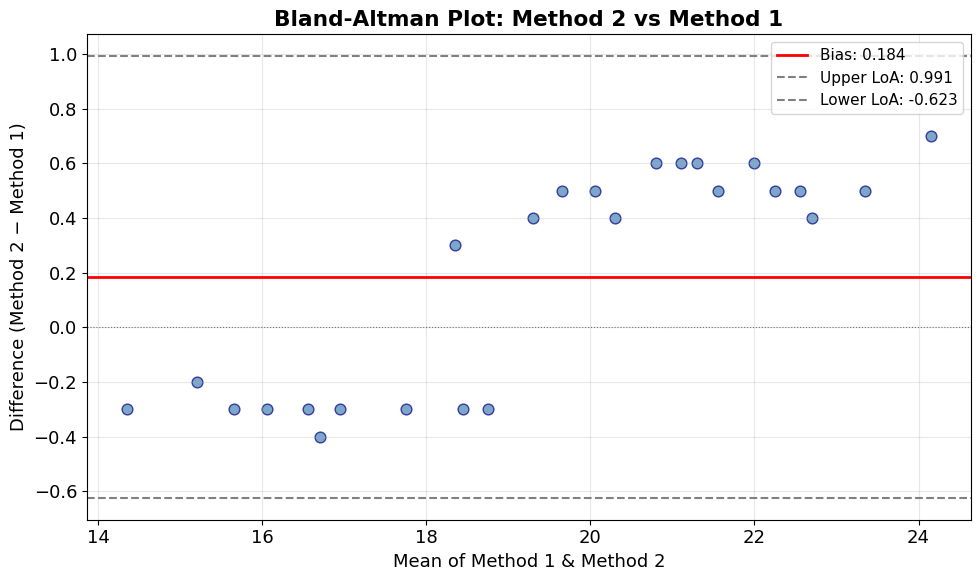


Results:
  Mean difference (bias): 0.184 log2 units
  SD of differences:      0.412 log2 units
  95% Limits of agreement: [-0.623, 0.991]

  In linear space, the bias corresponds to a 1.14-fold difference


In [ ]:
# Paired measurements from two MS quantification methods (log2 peak areas)
data = pd.DataFrame({
    'Method1': [18.2, 20.1, 15.3, 22.5, 19.8, 16.7, 21.3, 17.9, 23.1, 14.5,
                20.8, 18.6, 22.0, 16.2, 19.4, 21.7, 17.1, 23.8, 15.8, 20.5,
                18.9, 22.3, 16.9, 21.0, 19.1],
    'Method2': [18.5, 20.5, 15.1, 22.9, 20.3, 16.4, 21.8, 17.6, 23.6, 14.2,
                21.4, 18.3, 22.5, 15.9, 19.9, 22.3, 16.8, 24.5, 15.5, 21.1,
                18.6, 22.8, 16.5, 21.6, 19.5]
})

def bland_altman_plot(method1, method2, method1_name='Method 1', method2_name='Method 2'):
    """
    Create a Bland-Altman plot comparing two measurement methods.
    
    Parameters:
        method1, method2: arrays of paired measurements
        method1_name, method2_name: labels for the methods
    """
    # Step 1: Calculate the mean of each pair
    means = (method1 + method2) / 2       # ← This is given
    
    # Step 2: Calculate the difference for each pair
    diffs = method2 - method1             # ← Fill this in: new method minus reference
    
    # Step 3: Calculate the mean difference (bias) and SD of differences
    bias = np.mean(diffs)                 # ← Fill this in
    sd = np.std(diffs, ddof=1)            # ← Fill this in (use ddof=1 for sample SD)
    
    # Step 4: Calculate 95% limits of agreement
    upper_loa = bias + 1.96 * sd          # ← Fill this in
    lower_loa = bias - 1.96 * sd          # ← Fill this in
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(means, diffs, s=60, alpha=0.7, color='steelblue', edgecolors='navy')
    
    # Bias line
    ax.axhline(y=bias, color='red', linestyle='-', linewidth=2,
               label=f'Bias: {bias:.3f}')
    # Limits of agreement
    ax.axhline(y=upper_loa, color='gray', linestyle='--', linewidth=1.5,
               label=f'Upper LoA: {upper_loa:.3f}')
    ax.axhline(y=lower_loa, color='gray', linestyle='--', linewidth=1.5,
               label=f'Lower LoA: {lower_loa:.3f}')
    # Zero line
    ax.axhline(y=0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel(f'Mean of {method1_name} & {method2_name}')
    ax.set_ylabel(f'Difference ({method2_name} − {method1_name})')
    ax.set_title(f'Bland-Altman Plot: {method2_name} vs {method1_name}', fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return bias, sd, lower_loa, upper_loa

# Run the analysis
bias, sd, lower, upper = bland_altman_plot(
    data['Method1'], data['Method2'], 
    method1_name='Method 1', method2_name='Method 2'
)

print(f"\nResults:")
print(f"  Mean difference (bias): {bias:.3f} log2 units")
print(f"  SD of differences:      {sd:.3f} log2 units")
print(f"  95% Limits of agreement: [{lower:.3f}, {upper:.3f}]")
print(f"\n  In linear space, the bias corresponds to a {2**bias:.2f}-fold difference")

## Part 3: Detecting Proportional Bias

Sometimes the disagreement between methods isn't constant — it gets *worse* at higher (or lower) signal levels. This is called **proportional bias**.

**Exercise 2:** The data below comes from two methods where one has proportional bias. Create the Bland-Altman plot and look for a trend in the differences.

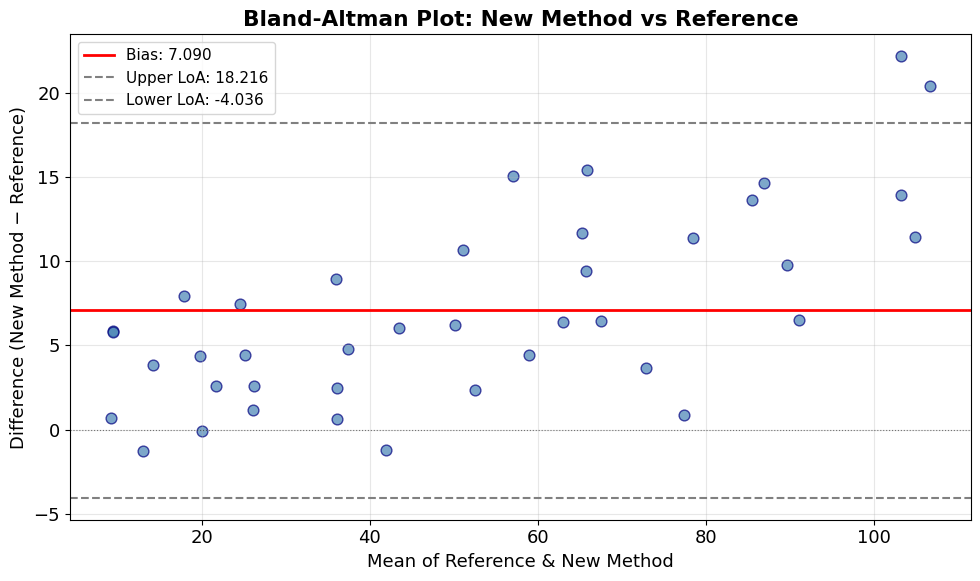


Test for proportional bias:
  Slope of differences vs means: 0.1288
  p-value: 0.0000
  → Significant proportional bias detected!
  → The disagreement between methods changes with the magnitude of measurement


In [ ]:
# Method with proportional bias: the new method reads increasingly high at higher concentrations
np.random.seed(42)
true_values = np.random.uniform(5, 100, 40)
ref_method = true_values + np.random.normal(0, 3, 40)
# New method has a proportional bias: multiplied by 1.05 (5% high) plus noise
new_method = true_values * 1.15 + np.random.normal(0, 3, 40)

# Students should see a SLOPE in the Bland-Altman plot
bias_result, sd_result, lower_result, upper_result = bland_altman_plot(
    ref_method, new_method,
    method1_name='Reference', method2_name='New Method'
)

# Test for proportional bias: regress differences on means
means_prop = (ref_method + new_method) / 2
diffs_prop = new_method - ref_method
slope, intercept, r_value, p_value, std_err = stats.linregress(means_prop, diffs_prop)

print(f"\nTest for proportional bias:")
print(f"  Slope of differences vs means: {slope:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  → Significant proportional bias detected!")
    print(f"  → The disagreement between methods changes with the magnitude of measurement")
else:
    print(f"  → No significant proportional bias")

## Part 4: Discussion Questions

Work through these with a partner:

1. **Bias vs precision:** You're comparing a new fast proteomics method to a gold-standard method. The Bland-Altman plot shows a constant bias of +0.5 log₂ units but tight limits of agreement (±0.3). Is the new method useful? When might a constant bias be acceptable?

2. **Proportional bias:** Your Bland-Altman plot shows differences that fan out at higher concentrations. What does this mean for how you should report uncertainty — should you use absolute error or relative error (%CV)?

3. **Sample size:** The limits of agreement themselves have uncertainty. With only 10 paired measurements, your LoA estimates are quite imprecise. How many paired measurements would you want for a robust method comparison? (Bland & Altman recommend at least 50.)

4. **Connection to noise types:** How does proportional bias in a Bland-Altman plot relate to the heteroscedastic vs homoscedastic noise distinction from the earlier worksheet?

**Key takeaways:**
- **Never use correlation alone** to assess agreement between methods
- The Bland-Altman plot reveals bias, proportional bias, and the practical limits of agreement
- A constant bias can often be corrected by calibration; proportional bias is harder to fix
- These concepts apply any time you compare methods: MS vs ELISA, TMT vs DIA, old instrument vs new instrument